# Exercise 4.A Introduction to Linear Regression

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

## Lab 1
### Running a sample script

In [8]:
# Sample dataset: hours studied vs. exam score
data = {
    'hours_studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'exam_score':    [52, 55, 60, 65, 68, 72, 75, 80, 85, 90]
}
df = pd.DataFrame(data)

# Step 1: Define features (X) and target (y)
X = df[['hours_studied']]   # 2D: double brackets give a DataFrame, not a Series
y = df['exam_score']        # 1D: single brackets give a Series

# Step 2: Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 3: Create the model and fit it to training data
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


### Working through the sample script

In [9]:
print(f'\nSlope (coefficient): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')


Slope (coefficient): 4.10
Intercept: 47.68


In [10]:
y_pred = model.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(1)))

Actual scores:  [85, 55]
Predicted scores: [np.float64(84.6), np.float64(55.9)]


In [11]:
r_squared = model.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


The R^2 score tells you how the regression model explains the variation in the data; in other words, how well does the regression model becomes "best fitted" for the data points given. It ranges from -1 (poor fit, worse than predicting average) to 0 (correlates just as well as predicting the mean) to 1 (explains exactly why the data is so). Since we have a r^2 score of .998, our model captures most, if not nearly all the patterns in the data, and that 0.2% of it is unexplained by the model.

C:\Users\Longley\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


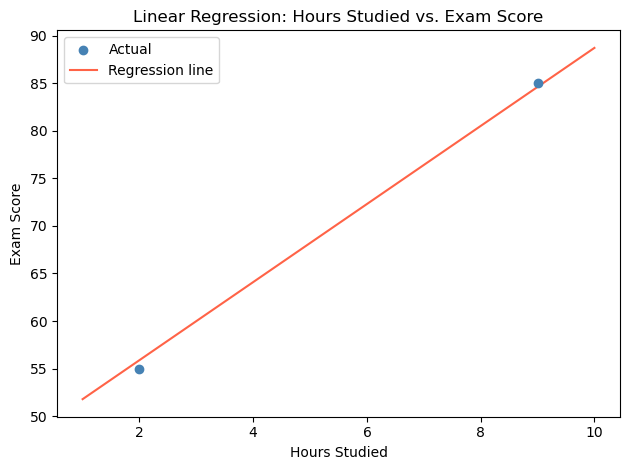

In [12]:
# Scatter plot: actual test data points
plt.scatter(X_test, y_test, color='steelblue', label='Actual',
zorder=3)
# Line: model predictions across the full range of X
x_range = np.linspace(
X['hours_studied'].min(),
X['hours_studied'].max(),
100).reshape(-1, 1)
y_line = model.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression: Hours Studied vs. Exam Score')
plt.legend()
plt.tight_layout()
plt.show()

The actual data points follow the regression line very closely, even to the origin. Predictions can be made by extrapolating from the regression line.

## Lab 2
### Building your own model

In [24]:
ad_data = {
'monthly_ad_spend': [500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500,
5000, 5500, 6000, 6500, 7000, 7500, 8000, 8500, 9000, 9500, 10000],
'monthly_revenue': [4200, 5100, 6800, 7400, 8900, 9200, 10500, 11800,
12400, 13100, 14200, 15600, 15900, 17200, 18100, 19400, 20200, 21500, 22100,
23800]
}

df_ads = pd.DataFrame(ad_data)
df_ads

,monthly_ad_spend,monthly_revenue
0,500,4200
1,1000,5100
2,1500,6800
3,2000,7400
4,2500,8900
5,3000,9200
6,3500,10500
7,4000,11800
8,4500,12400
9,5000,13100


In [25]:
X2 = df_ads[["monthly_ad_spend"]]
y2 = df_ads["monthly_revenue"]

print(X2.shape)
print(y2.shape)

(20, 1)
(20,)


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

In [27]:
model2 = LinearRegression()
model2.fit(X_train, y_train)

print('Model trained successfully.')

Model trained successfully.


In [28]:
print(f'\nSlope (coefficient): {model2.coef_[0]:.2f}')  # for each additional monthly ad spend in dollars, the predicted monthly revenue increases by $2
print(f'Intercept: {model2.intercept_:.2f}')


Slope (coefficient): 1.96
Intercept: 3625.89


### Making predictions and evaluating the model

In [29]:
y_pred = model2.predict(X_test)
print('Actual scores: ', list(y_test))
print('Predicted scores:', list(y_pred.round(2)))

Actual scores:  [4200, 21500, 19400, 5100]
Predicted scores: [np.float64(4603.85), np.float64(21229.03), np.float64(19273.13), np.float64(5581.8)]


In [30]:
r_squared = model2.score(X_test, y_test)
print(f'R² score: {r_squared:.3f}')

R² score: 0.998


This model appears to be a good fit too. 99.8% of the variation in revenue is explained by ad spend.

### Visualizing the results

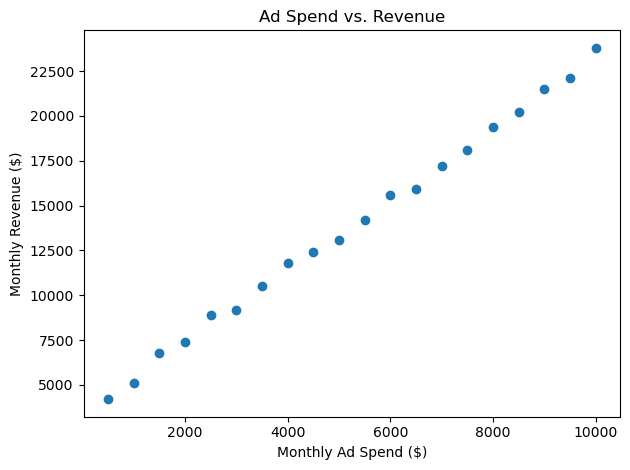

In [35]:
# Scatter plot: actual test data points
plt.scatter(X2, y2)

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.tight_layout()
plt.show()

C:\Users\Longley\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


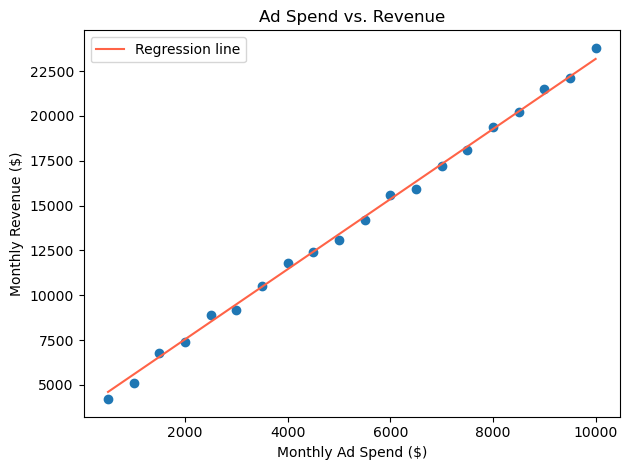

In [36]:
# Scatter plot: actual test data points
plt.scatter(X2, y2)

x_range = np.linspace(
X2['monthly_ad_spend'].min(),
X2['monthly_ad_spend'].max(),
100).reshape(-1, 1)
y_line = model2.predict(x_range)
plt.plot(x_range, y_line, color='tomato', label='Regression line')

plt.xlabel('Monthly Ad Spend ($)')
plt.ylabel('Monthly Revenue ($)')
plt.title('Ad Spend vs. Revenue')
plt.legend()
plt.tight_layout()
plt.show()

I would be skeptical of what the R^2 score told me as it seems to fit it nicely, but not perfectly.